<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_pr_08_PR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

## 1. Data Preparation

First, we need to load and preprocess our image data. For this example, I'll assume you have your images organized in directories like this:

```
./dataset/
  ├── training/
  │   ├── category_a/
  │   │   ├── img1.jpg
  │   │   └── img2.jpg
  │   └── category_b/
  │       ├── img3.jpg
  │       └── img4.jpg
  └── validation/
      ├── category_a/
      │   ├── img5.jpg
      │   └── img6.jpg
      └── category_b/
          ├── img7.jpg
          └── img8.jpg
```

We'll use `ImageDataGenerator` from Keras to handle data loading, augmentation, and splitting into batches.

In [2]:
import zipfile
import shutil
import pathlib

# Define image dimensions and batch size
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

# --- Start of modifications to download and extract dataset ---

# Use a reliable direct download link for the flower_photos dataset
_URL = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
zip_file_name = 'flower_photos.tgz'

# Clean up previous attempts if any
if os.path.exists(zip_file_name):
    os.remove(zip_file_name)
if os.path.exists(os.path.join('.', 'flower_photos')):
    shutil.rmtree(os.path.join('.', 'flower_photos'))
if os.path.exists(os.path.join('.', 'flower_dataset')):
    shutil.rmtree(os.path.join('.', 'flower_dataset'))

print(f"Downloading dataset from {_URL}...")
!wget -O {zip_file_name} {_URL}

# Extract the tar.gz file
!tar -xf {zip_file_name}

# Base directory for the extracted flowers
base_dir_flowers = os.path.join('.', 'flower_photos')

# Define the categories we are interested in
TARGET_CLASSES = ['roses', 'sunflowers']

# Create a new base directory for our processed flower dataset
processed_dataset_dir = os.path.join('.', 'flower_dataset')

# Create train and validation directories within our new dataset structure
train_dir = os.path.join(processed_dataset_dir, 'training')
validation_dir = os.path.join(processed_dataset_dir, 'validation')

for class_name in TARGET_CLASSES:
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(validation_dir, class_name), exist_ok=True)

# Split data into training and validation (80% train, 20% validation)
SPLIT_RATIO = 0.8

for class_name in TARGET_CLASSES:
    class_path = os.path.join(base_dir_flowers, class_name)
    images = list(pathlib.Path(class_path).glob('*.jpg'))
    np.random.shuffle(images)

    num_train = int(len(images) * SPLIT_RATIO)

    for i, img_path in enumerate(images):
        if i < num_train:
            shutil.copy(img_path, os.path.join(train_dir, class_name, img_path.name))
        else:
            shutil.copy(img_path, os.path.join(validation_dir, class_name, img_path.name))

print(f"Using training images from: {train_dir}")
print(f"Using validation images from: {validation_dir}")
# --- End of modifications ---

# Create data generators
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary' # Binary classification for roses vs sunflowers
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

--2026-08-18 06:26:28--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.194.207, 74.125.69.207, 64.233.181.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.194.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz’

flower_photos.tgz   100%[===================>] 218.21M   161MB/s    in 1.4s    

2026-08-18 06:26:30 (161 MB/s) - ‘flower_photos.tgz’ saved [228813984/228813984]

Using training images from: ./flower_dataset/training
Using validation images from: ./flower_dataset/validation
Found 1071 images belonging to 2 classes.
Found 269 images belonging to 2 classes.


In [3]:
model = models.Sequential([
    tf.keras.Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Use 'sigmoid' for binary classification
])

model.summary()

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    train_generator,
    steps_per_epoch=int(np.ceil(train_generator.samples / BATCH_SIZE)),
    epochs=1, # You can adjust the number of epochs
    validation_data=validation_generator,
    validation_steps=int(np.ceil(validation_generator.samples / BATCH_SIZE))
)

34/34 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.7386 - loss: 0.6600 - val_accuracy: 0.8736 - val_loss: 0.3101


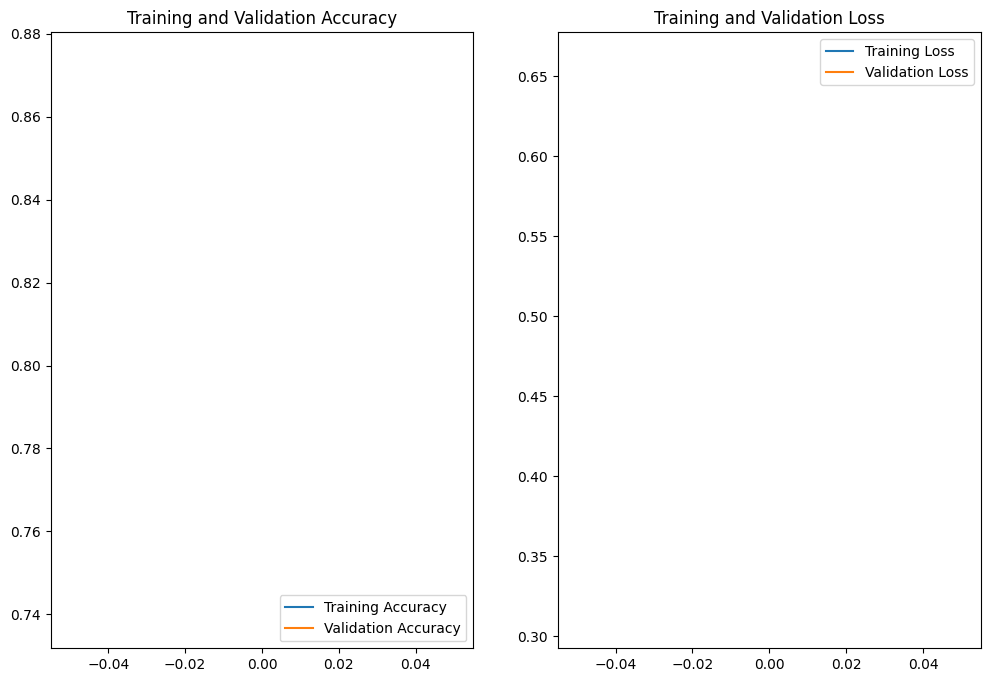

In [5]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step


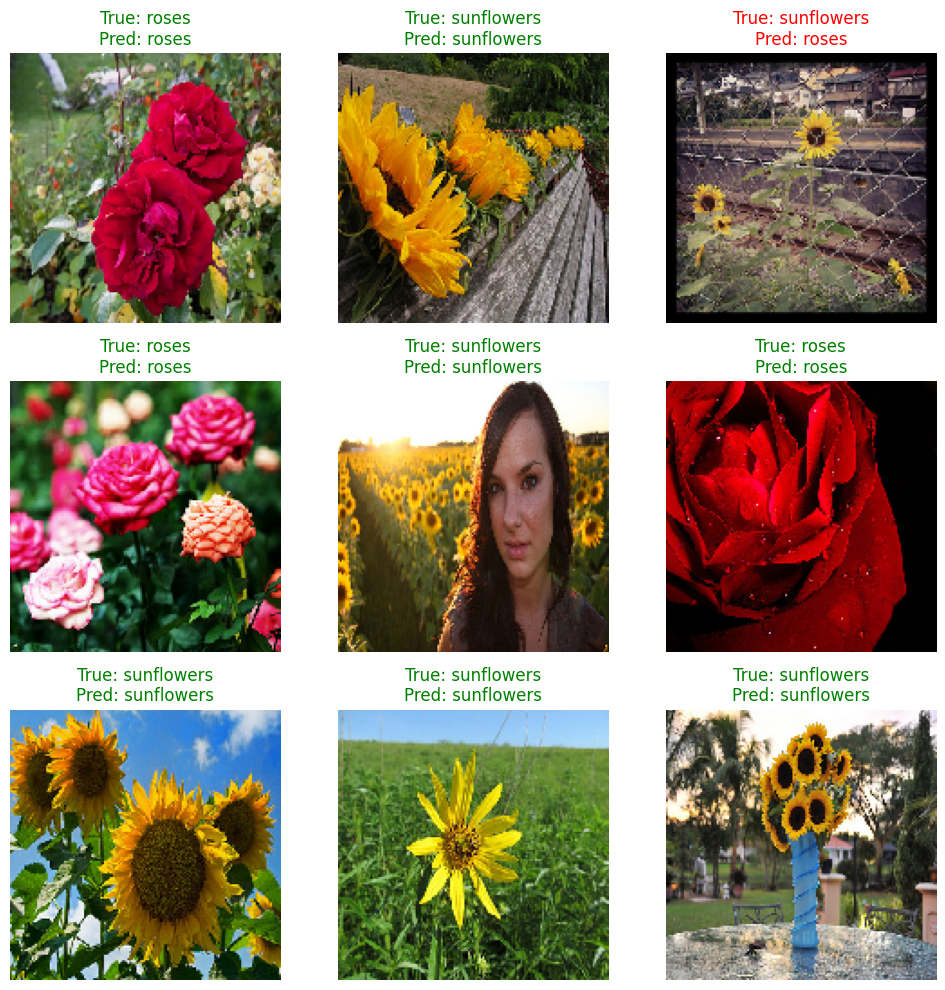

In [6]:
# Get a batch of validation data
val_images, val_labels = next(validation_generator)

# Make predictions on this batch
predictions = model.predict(val_images)
predicted_classes = (predictions > 0.5).astype(int) # Convert probabilities to binary classes (0 or 1)

# Get class names from the generator
class_names = list(train_generator.class_indices.keys())
# Reverse the dictionary to map class indices back to class names
class_names_map = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(val_images[i])

    true_label = class_names_map[int(val_labels[i])]
    predicted_label = class_names_map[predicted_classes[i][0]]

    title_color = "green" if true_label == predicted_label else "red"

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    plt.axis("off")
plt.tight_layout()
plt.show()